# Importing the Libraries

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm # Using .api imports the public access version of statsmodels, which is a library that handles 
# statistical models
import os
import warnings # This is a library that handles warnings
from pylab import rcParams

warnings.filterwarnings("ignore") # Disable deprecation warnings that could indicate, for instance, a suspended library or 
# feature, these are more relevant to developers

plt.style.use('fivethirtyeight') # This is a styling option for how the plots will appear

In [47]:
# Define the file path
path = r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6'

# Correctly reading the pickle file
df = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'revised1.pkl'))

In [48]:
df.shape

(2055, 16)

In [49]:
df.columns

Index(['Country name', 'Year', 'Life Ladder', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Positive affect', 'Negative affect',
       'Happiness score', 'z_score', 'Happiness Category', 'Country Code',
       'IncomeGroup'],
      dtype='object')

# Check for null or duplicate values

In [50]:
df.isnull().sum() 

Country name                        0
Year                                0
Life Ladder                         0
Log GDP per capita                  0
Social support                      0
Healthy life expectancy at birth    0
Freedom to make life choices        0
Generosity                          0
Perceptions of corruption           0
Positive affect                     0
Negative affect                     0
Happiness score                     0
z_score                             0
Happiness Category                  0
Country Code                        0
IncomeGroup                         0
dtype: int64

In [51]:
dups = df.duplicated()
dups.sum()

0

# Create a subset and set 'Year' as the index column

In [54]:
sub1 = df[['Year', 'Happiness score', 'Log GDP per capita', 'Healthy life expectancy at birth', 
          'Social support', 'Freedom to make life choices', 'Generosity', 
          'Perceptions of corruption', 'Positive affect', 'Negative affect']].copy()

# Keep 'Year' as a column and also set it as index
sub1.set_index('Year', inplace=True)

I created the subset `sub1` because I need to perform time series analysis on key happiness-related variables. My original dataset contained several categorical and unnecessary columns, so I removed them to focus on numerical variables relevant to my analysis.  

I kept 'Year' as my index column in order to structure the data for time series operations. I selected variables like 'Happiness score', 'Log GDP per capita', 'Healthy life expectancy at birth', 'Social support' and others because they influence happiness and are crucial for my analysis.  

I need to decompose the data into trend, seasonal and residual components. To do this effectively, I must remove categorical variables like 'Country name' and 'IncomeGroup', as they are irrelevant to time series modeling.  

Next, I will conduct a Dickey-Fuller test to check for stationarity. If the data isn’t stationary, I will apply differencing to stabilize the mean and variance over time. Preparing this subset ensures that my data is clean and ready for further analysis.

In [73]:
sub1.columns

Index(['Happiness score', 'Log GDP per capita',
       'Healthy life expectancy at birth', 'Social support',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Positive affect', 'Negative affect'],
      dtype='object')

# Create a line chart of the data

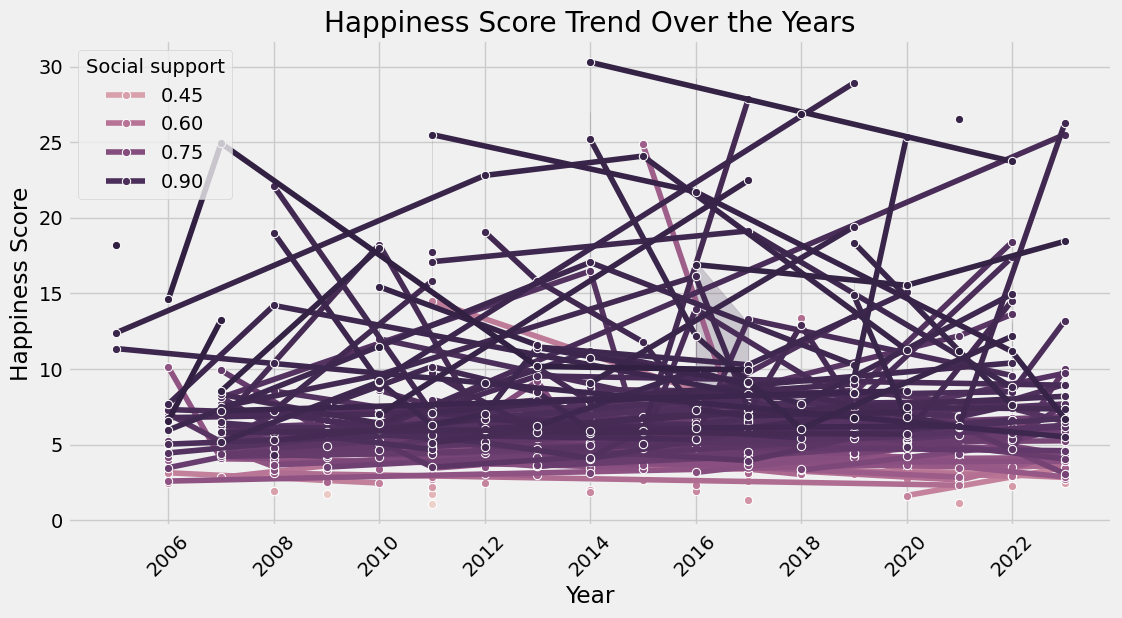

In [56]:
# Resample the data by selecting every 3rd or 4th year to reduce the number of points
sub_resampled = sub1.iloc[::3]  # Select every 3rd year 

# Set figure size
plt.figure(figsize=(12, 6))

# Plot the line chart for Happiness Score over the years
sns.lineplot(data=sub_resampled, x='Year', y='Happiness score', hue='Social support', marker='o')

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Happiness Score')
plt.title('Happiness Score Trend Over the Years')

# Format the x-axis to display only the year (ensure the 'Year' is shown properly)
plt.xticks(rotation=45)  # Rotate if labels are crowded
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Ensure years are treated as integers

# Save the figure
plt.savefig(f"{path}\\Visualisations\\happiness_trends_over_years.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

# Time Series Analysis : Decomposition

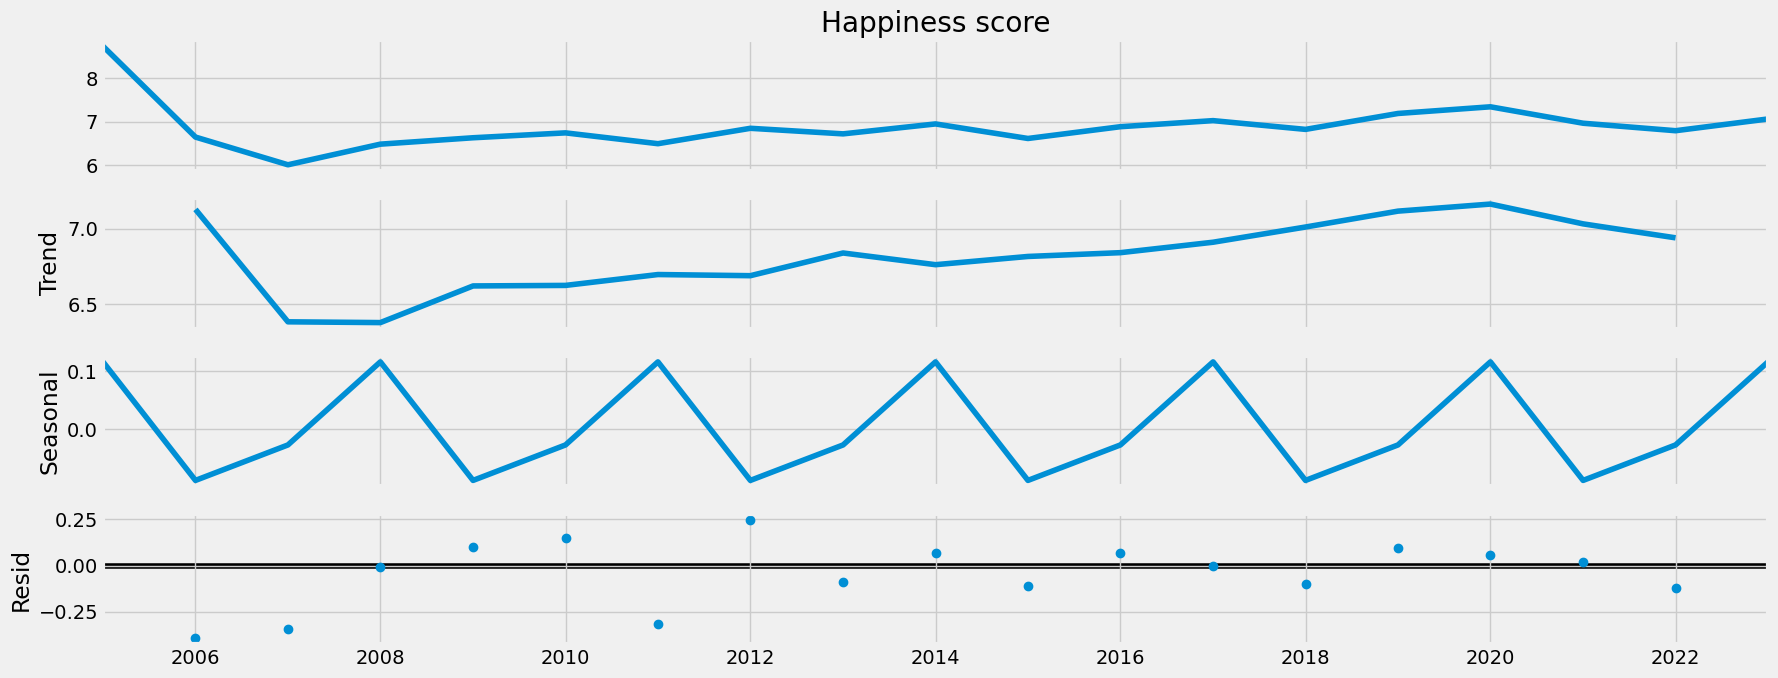

In [71]:
# Grouped by 'Year' and taken the mean
sub = sub1.groupby('Year').mean()

# Ensure 'Year' is in proper datetime format (if not done previously)
sub.index = pd.to_datetime(sub.index, format='%Y')

# Now select the specific column you want to decompose, e.g., 'Happiness score'
decomposition = sm.tsa.seasonal_decompose(sub['Happiness score'], model='additive', period=3)

# Define figure size

rcParams['figure.figsize'] = 18, 7
# Plot the components
decomposition.plot()

plt.savefig(os.path.join(path, "Visualisations", "hs_decomposition.png"), dpi=300, bbox_inches='tight')

plt.show()

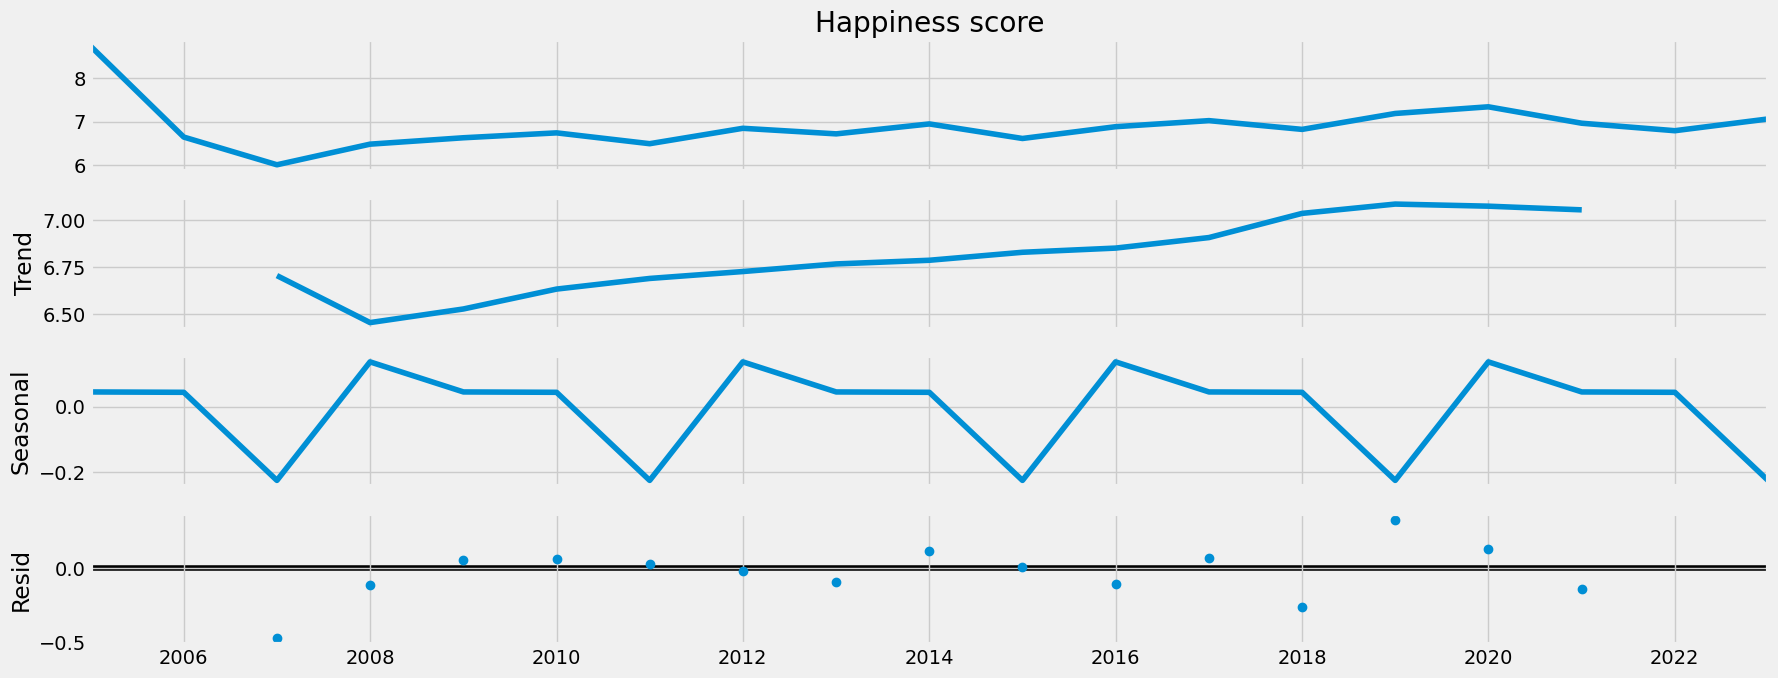

In [63]:
# If the data is already in time series format with a proper datetime index
decomposition = sm.tsa.seasonal_decompose(sub['Happiness score'], model='additive', period=4)  # If monthly data exists
decomposition.plot()
plt.show()

### Time Series Decomposition Analysis

The decomposition plot breaks down the `Happiness score` time series into four components:

- **Observed**: The original data trend.  
- **Trend**: The overall long-term movement.  
- **Seasonal**: The repeating patterns or cycles (if present).  
- **Residual**: The unexplained variations after removing trend and seasonality.  

#### Insights:

1. **Trend Component**:  
   It shows the general direction of happiness scores. An upward trend indicates improving well-being, while a downward trend suggests worsening conditions.  

2. **Seasonality Component**:  
   If present, it captures recurring fluctuations, suggesting cyclical effects, such as seasonal variations.  

3. **Residual Component**:  
   This shows randomness in the data that the trend and seasonality don't explain. Large residuals may signal external factors like economic shifts or crises. 

# Test for Stationarity

In [66]:
from statsmodels.tsa.stattools import adfuller # Import the adfuller() function

def dickey_fuller(timeseries): # Define the function
    # Perform the Dickey-Fuller test:
    print ('Dickey-Fuller Stationarity test:')
    test = adfuller(timeseries, autolag='AIC')
    result = pd.Series(test[0:4], index=['Test Statistic','p-value','Number of Lags Used','Number of Observations Used'])
    for key, value in test[4].items():
       result['Critical Value (%s)' % key] = value
    print(result)

# Apply the test using the function on the time series
dickey_fuller(sub['Happiness score'])  # Replace 'Happiness score' with your desired column

Dickey-Fuller Stationarity test:
Test Statistic                -6.745556e+00
p-value                        3.041505e-09
Number of Lags Used            0.000000e+00
Number of Observations Used    1.800000e+01
Critical Value (1%)           -3.859073e+00
Critical Value (5%)           -3.042046e+00
Critical Value (10%)          -2.660906e+00
dtype: float64


Summary Interpretation : 

I found that the results of the Dickey-Fuller Stationarity test indicate that my time series is **stationary**. The test statistic is **-6.745556**, which is more negative than the critical values at all confidence levels (1%, 5%, and 10%). Moreover, the p-value is extremely small (\(3.04 \times 10^{-9}\)), well below the significance threshold of 0.05. This allows me to reject the null hypothesis of non-stationarity.

Since the data is already stationary, there is no need for me to perform additional rounds of differencing. Differencing is typically applied to make non-stationary data stationary, but since the test shows that my series has passed the stationarity test, I can proceed with my analysis without further transformation. I can confidently reject the null hypothesis that the series has a unit root and is non-stationary.

# Check out a plot of autocorrelations

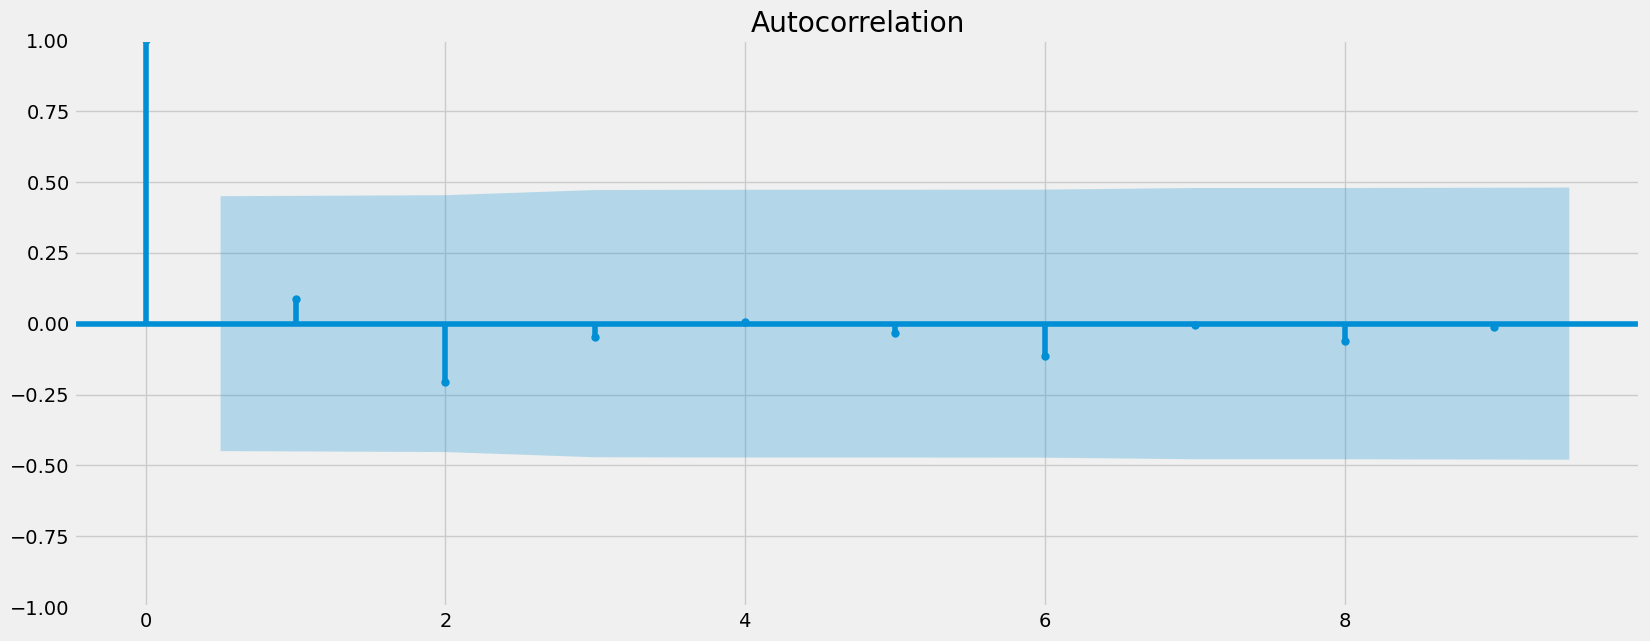

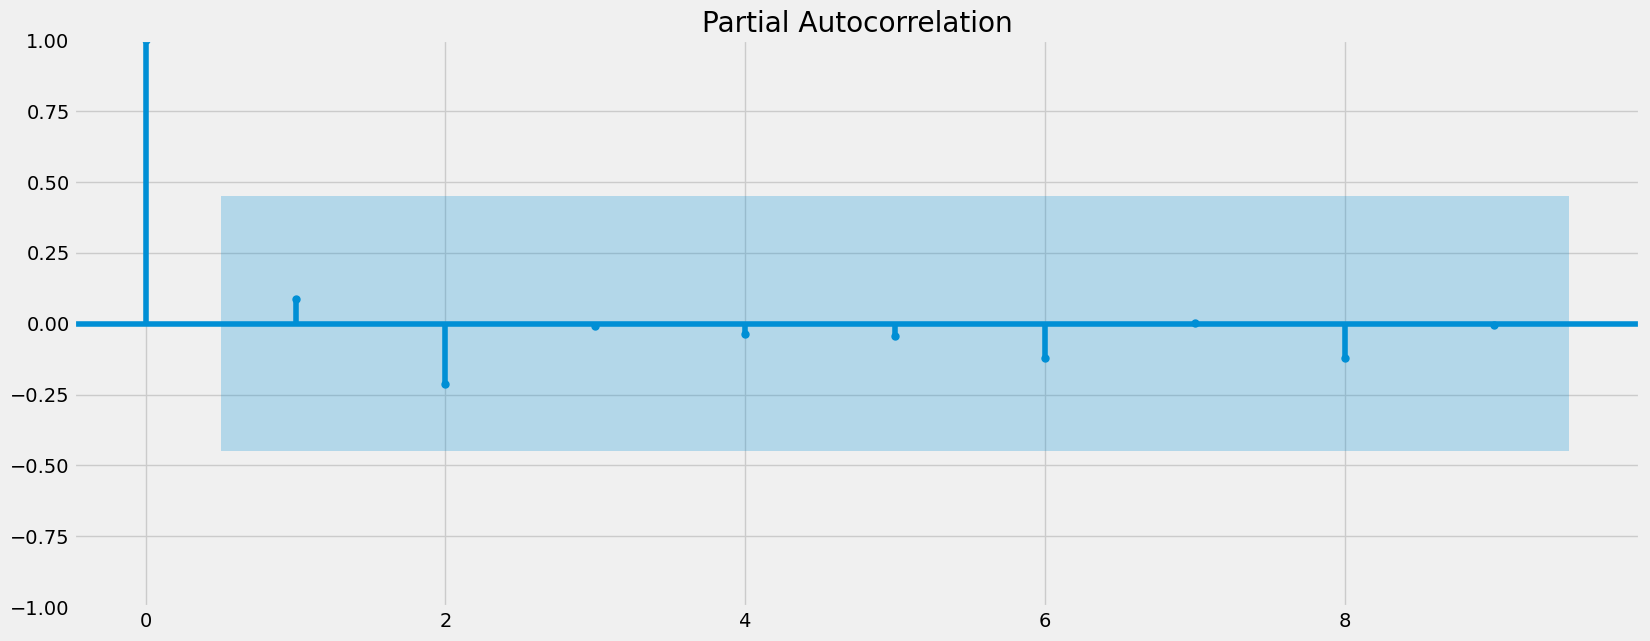

In [72]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot the autocorrelation for the 'Happiness score' column
plot_acf(sub['Happiness score'])
plt.savefig(os.path.join(path, "Visualisations", "happiness_autocor.png"), dpi=300, bbox_inches='tight')
plt.show()

# Plot the partial autocorrelation for the 'Happiness score' column
plot_pacf(sub['Happiness score'])

plt.show()